In [1]:
!pip install transformers torch torchvision pillow requests matplotlib scikit-learn numpy

  Attempting uninstall: click
    Found existing installation: click 8.4.1
    Uninstalling click-8.4.1:
      Successfully uninstalled click-8.4.1


In [2]:
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from PIL import Image
from io import BytesIO
from sklearn.metrics.pairwise import cosine_similarity
from transformers import ViTModel, ViTImageProcessor

print(" All libraries imported!")
print(f" PyTorch  : {torch.__version__}")
print(f" Device   : {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

 All libraries imported!
 PyTorch  : 2.13.0+cpu
 Device   : CPU


In [3]:
MODEL_NAME = "google/vit-base-patch16-224"

print(f" Loading model: {MODEL_NAME}")
print("   First run downloads ~350 MB ...")

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
model     = ViTModel.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)
model.eval()

print(f"\n ViT model loaded on: {device.upper()}")
print(f" Feature vector size: 768 dimensions (CLS token)")

 Loading model: google/vit-base-patch16-224
   First run downloads ~350 MB ...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 ViT model loaded on: CPU
 Feature vector size: 768 dimensions (CLS token)


In [4]:
def load_image(url):
    """Load an image from URL and return PIL Image (RGB)."""
    try:
        response = requests.get(url, timeout=10)
        image    = Image.open(BytesIO(response.content)).convert("RGB")
        return image
    except Exception as e:
        print(f"    Could not load {url}: {e}")
        return None


def extract_features(image):
    """
    Pass a PIL image through ViT and return the
    CLS token embedding as a NumPy vector (shape: 768,).
    """
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    # CLS token = outputs.last_hidden_state[:, 0, :]
    cls_vector = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    return cls_vector


def get_similarity(vec_a, vec_b):
    """Compute cosine similarity between two feature vectors."""
    score = cosine_similarity(vec_a.reshape(1, -1), vec_b.reshape(1, -1))[0][0]
    return float(score)


def similarity_label(score):
    """Return a human-readable label based on the score."""
    if score >= 0.90:
        return " Very Similar"
    elif score >= 0.75:
        return " Somewhat Similar"
    elif score >= 0.60:
        return " Weakly Similar"
    else:
        return " Unusual / Different Category"


print(" Helper functions ready!")

 Helper functions ready!


In [5]:
# 7 cat image URLs (Unsplash / public domain)
cat_urls = [
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400",
    "https://images.unsplash.com/photo-1573865526739-10659fec78a5?w=400",
    "https://images.unsplash.com/photo-1526336024174-e58f5cdd8e13?w=400",
    "https://images.unsplash.com/photo-1561948955-570b270e7c36?w=400",
    "https://images.unsplash.com/photo-1533743983669-94fa5c4338ec?w=400",
    "https://images.unsplash.com/photo-1495360010541-f48722b34f7d?w=400",
    "https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=400",
]

print(" Loading 7 cat images and extracting feature vectors...\n")

cat_images   = []
cat_features = []

for i, url in enumerate(cat_urls, 1):
    img = load_image(url)
    if img:
        feat = extract_features(img)
        cat_images.append(img)
        cat_features.append(feat)
        print(f"  Cat image {i} loaded  |  feature shape: {feat.shape}")

cat_features = np.array(cat_features)
print(f"\n Reference database ready: {len(cat_images)} cat images stored.")
print(f" Feature matrix shape: {cat_features.shape}  (images × 768)")

 Loading 7 cat images and extracting feature vectors...

  Cat image 1 loaded  |  feature shape: (768,)
  Cat image 2 loaded  |  feature shape: (768,)
  Cat image 3 loaded  |  feature shape: (768,)
  Cat image 4 loaded  |  feature shape: (768,)
  Cat image 5 loaded  |  feature shape: (768,)
  Cat image 6 loaded  |  feature shape: (768,)
  Cat image 7 loaded  |  feature shape: (768,)

 Reference database ready: 7 cat images stored.
 Feature matrix shape: (7, 768)  (images × 768)


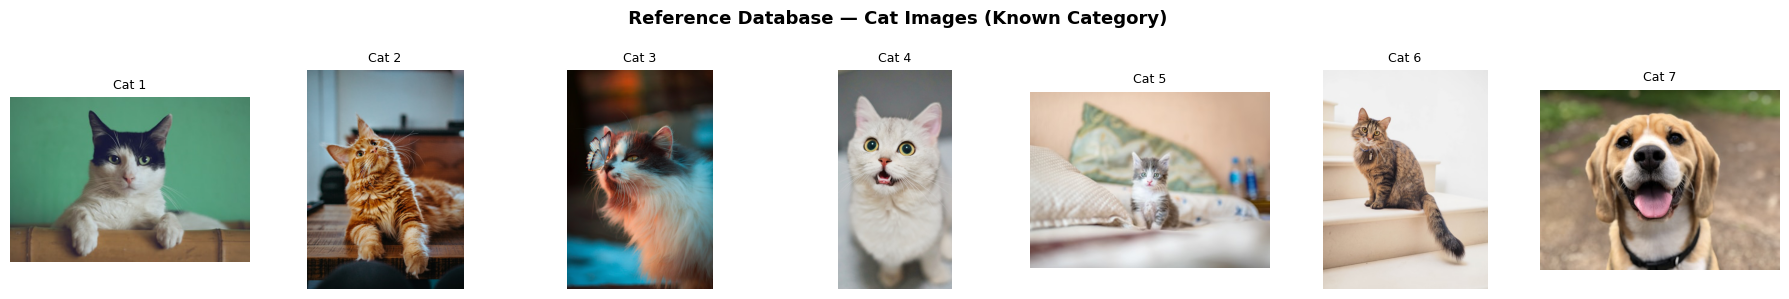

 Reference database preview shown.


In [6]:
fig, axes = plt.subplots(1, len(cat_images), figsize=(18, 3))
fig.suptitle(" Reference Database — Cat Images (Known Category)",
             fontsize=13, fontweight="bold")

for i, (ax, img) in enumerate(zip(axes, cat_images), 1):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Cat {i}", fontsize=9)

plt.tight_layout()
plt.show()
print(" Reference database preview shown.")

In [7]:
def find_most_similar(query_image, query_label="Query Image"):
    """
    Compare a query image against the reference cat database.
    Displays: input image | most similar stored image | similarity scores.
    """
    print(f"\n{'='*60}")
    print(f"   Query: {query_label}")
    print(f"{'='*60}")

    # Extract feature vector for the query image
    query_feat = extract_features(query_image)

    # Compute cosine similarity with all stored cat features
    scores = [get_similarity(query_feat, ref_feat) for ref_feat in cat_features]

    best_idx   = int(np.argmax(scores))
    best_score = scores[best_idx]
    avg_score  = float(np.mean(scores))
    label      = similarity_label(best_score)

    # ── Display ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 5))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 2, 1.4])

    # Panel 1 — Query image
    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(query_image)
    ax0.axis("off")
    ax0.set_title(f" Input Image\n{query_label}",
                  fontsize=11, fontweight="bold")

    # Panel 2 — Most similar stored image
    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(cat_images[best_idx])
    ax1.axis("off")
    ax1.set_title(f" Most Similar\nCat #{best_idx+1} from Database",
                  fontsize=11, fontweight="bold")

    # Panel 3 — Score card
    ax2 = fig.add_subplot(gs[2])
    ax2.axis("off")

    all_scores_str = "\n".join(
        [f"  Cat {i+1}: {s:.4f}" for i, s in enumerate(scores)]
    )

    card_text = (
        f"SIMILARITY REPORT\n"
        f"{'─'*26}\n"
        f"Best Match : Cat #{best_idx+1}\n"
        f"Best Score : {best_score:.4f}\n"
        f"Avg Score  : {avg_score:.4f}\n"
        f"Verdict    :\n{label}\n"
        f"{'─'*26}\n"
        f"All Scores:\n{all_scores_str}"
    )

    ax2.text(
        0.05, 0.95, card_text,
        transform=ax2.transAxes,
        fontsize=9, verticalalignment="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.6",
                  facecolor="#fffde7", edgecolor="#999", linewidth=1)
    )

    plt.suptitle(f"Similarity Detection Result — {label}",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"  Best Match  → Cat #{best_idx+1}  |  Score: {best_score:.4f}")
    print(f"  Avg Score   → {avg_score:.4f}")
    print(f"  Verdict     → {label}")

    return scores, best_idx, best_score


print(" Query function defined!")

 Query function defined!



   Query: New Cat (Similar)


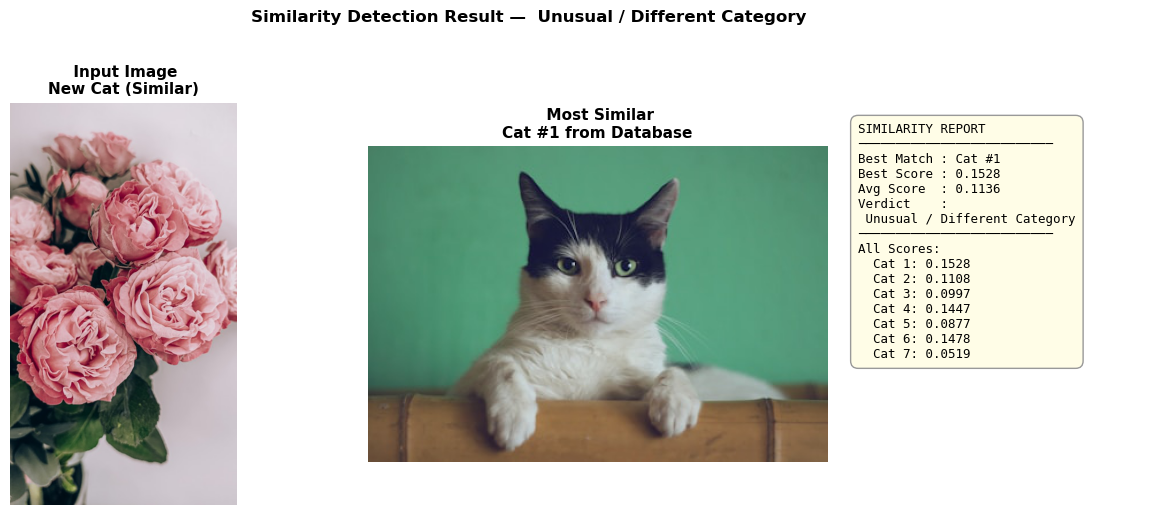

  Best Match  → Cat #1  |  Score: 0.1528
  Avg Score   → 0.1136
  Verdict     →  Unusual / Different Category


In [8]:
query_cat_url = "https://images.unsplash.com/photo-1582794543139-8ac9cb0f7b11?w=400"
query_cat     = load_image(query_cat_url)

scores_cat, best_cat, top_cat = find_most_similar(query_cat, query_label="New Cat (Similar)")


   Query: Dog (Different Category)


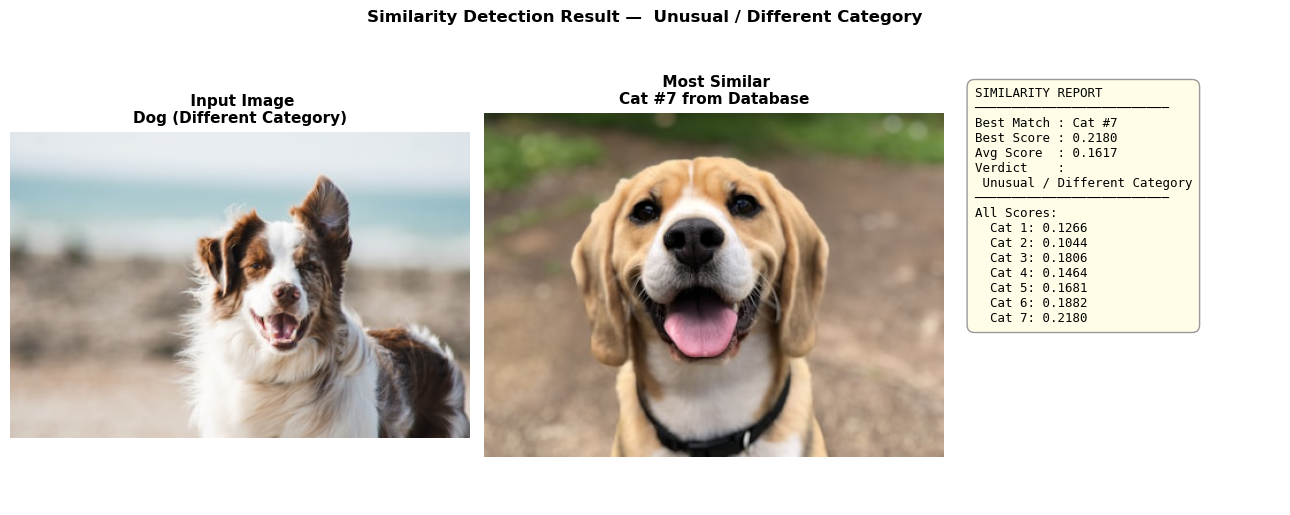

  Best Match  → Cat #7  |  Score: 0.2180
  Avg Score   → 0.1617
  Verdict     →  Unusual / Different Category


In [9]:
query_dog_url = "https://images.unsplash.com/photo-1587300003388-59208cc962cb?w=400"
query_dog     = load_image(query_dog_url)

scores_dog, best_dog, top_dog = find_most_similar(query_dog, query_label="Dog (Different Category)")


   Query: City Street (Very Different)


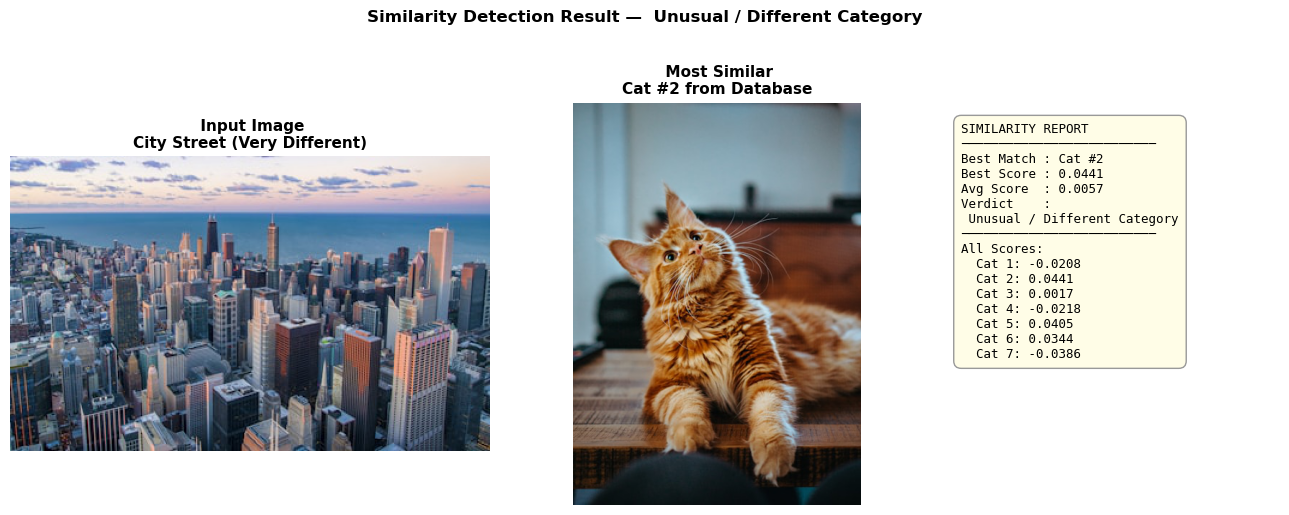

  Best Match  → Cat #2  |  Score: 0.0441
  Avg Score   → 0.0057
  Verdict     →  Unusual / Different Category


In [10]:
query_city_url = "https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=400"
query_city     = load_image(query_city_url)

scores_city, best_city, top_city = find_most_similar(query_city, query_label="City Street (Very Different)")

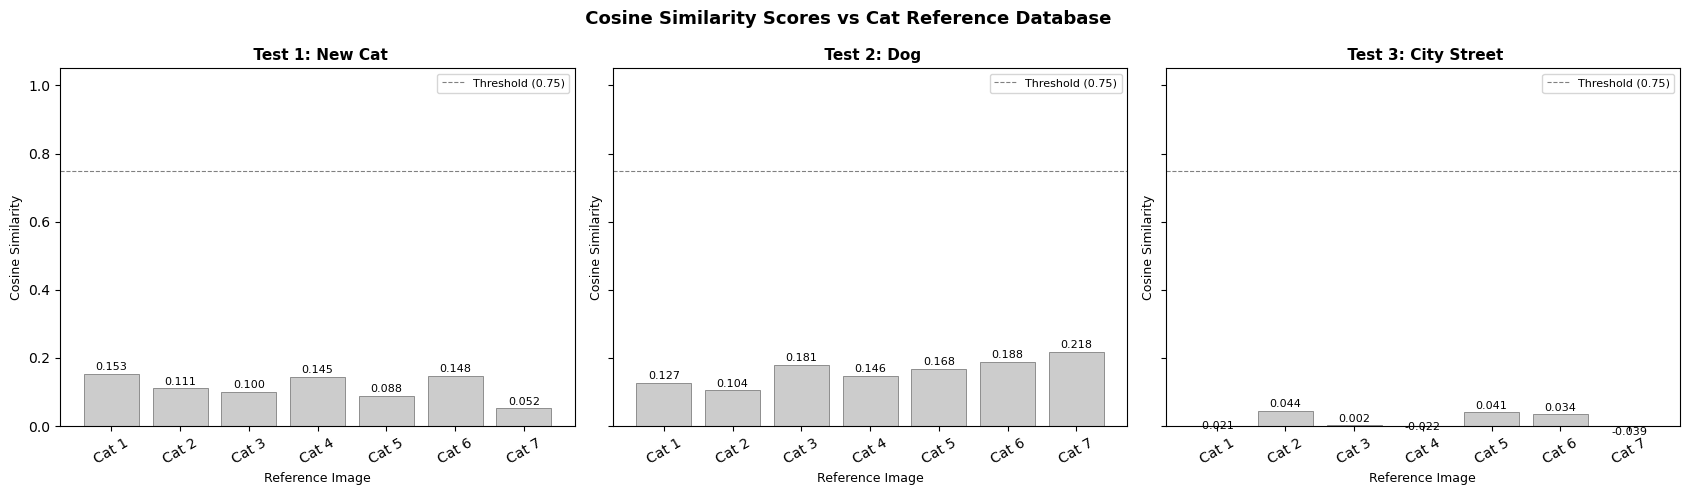

 Bar chart saved as similarity_comparison.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
fig.suptitle(" Cosine Similarity Scores vs Cat Reference Database",
             fontsize=13, fontweight="bold")

test_cases = [
    (scores_cat,  top_cat,  " Test 1: New Cat",      "#4caf50"),
    (scores_dog,  top_dog,  " Test 2: Dog",          "#ff9800"),
    (scores_city, top_city, " Test 3: City Street",  "#f44336"),
]

x_labels = [f"Cat {i+1}" for i in range(len(cat_images))]

for ax, (scores, best_idx, title, color) in zip(axes, test_cases):
    bar_colors = [color if i == best_idx else "#cccccc" for i in range(len(scores))]
    bars = ax.bar(x_labels, scores, color=bar_colors, edgecolor="gray", linewidth=0.6)

    # Annotate bars
    for bar, s in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{s:.3f}",
                ha="center", va="bottom", fontsize=8)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Reference Image", fontsize=9)
    ax.set_ylabel("Cosine Similarity", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.75, color="gray", linestyle="--", linewidth=0.8, label="Threshold (0.75)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("similarity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Bar chart saved as similarity_comparison.png")

In [12]:
results = [
    ("New Cat (Similar)",        top_cat,  np.mean(scores_cat)),
    ("Dog (Different)",          top_dog,  np.mean(scores_dog)),
    ("City Street (Very Diff.)", top_city, np.mean(scores_city)),
]

print("\n" + "=" * 68)
print(f"  {'Query Image':<28} {'Best Score':>11} {'Avg Score':>10}  Verdict")
print("=" * 68)
for name, best_idx, avg in results:
    best_scores = {
        "New Cat (Similar)":        top_cat,
        "Dog (Different)":          top_dog,
        "City Street (Very Diff.)": top_city,
    }
    best_score_map = {
        "New Cat (Similar)":        max(scores_cat),
        "Dog (Different)":          max(scores_dog),
        "City Street (Very Diff.)": max(scores_city),
    }
    bs = best_score_map[name]
    print(f"  {name:<28} {bs:>11.4f} {avg:>10.4f}  {similarity_label(bs)}")
print("=" * 68)

print("""
KEY INSIGHT:
  • High cosine similarity (≥ 0.90) → Same category (cat vs cat)
  • Medium similarity    (0.60–0.75) → Related but different (dog vs cat)
  • Low cosine similarity (< 0.60)   → Completely different (city vs cat)

This confirms that ViT feature vectors effectively capture
visual semantics — no training required!
""")


  Query Image                   Best Score  Avg Score  Verdict
  New Cat (Similar)                 0.1528     0.1136   Unusual / Different Category
  Dog (Different)                   0.2180     0.1617   Unusual / Different Category
  City Street (Very Diff.)          0.0441     0.0057   Unusual / Different Category

KEY INSIGHT:
  • High cosine similarity (≥ 0.90) → Same category (cat vs cat)
  • Medium similarity    (0.60–0.75) → Related but different (dog vs cat)
  • Low cosine similarity (< 0.60)   → Completely different (city vs cat)

This confirms that ViT feature vectors effectively capture
visual semantics — no training required!



In [13]:
# ── Option A: From URL ────────────────────────────────────────────────────────
# my_url   = "https://paste-your-image-url-here.jpg"
# my_image = load_image(my_url)
# find_most_similar(my_image, query_label="My Custom Image")

# ── Option B: From local file ─────────────────────────────────────────────────
# my_image = Image.open("my_photo.jpg").convert("RGB")
# find_most_similar(my_image, query_label="My Custom Image")

print(" Uncomment one option above and run with your own image!")

💡 Uncomment one option above and run with your own image!
